In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [17]:
import tensorflow as tf
model = tf.keras.models.load_model("modello.keras")

In [18]:
import pickle

with open("training_history.pkl", "rb") as f:
    history_dict = pickle.load(f)

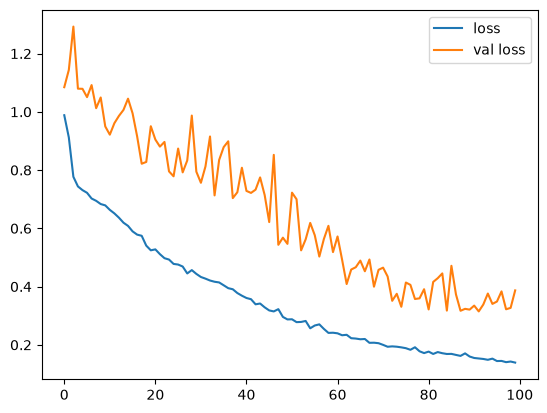

In [19]:
import matplotlib.pyplot as plt

plt.plot(history_dict["loss"])
plt.plot(history_dict["val_loss"])
plt.legend(["loss", "val loss"])
plt.show()

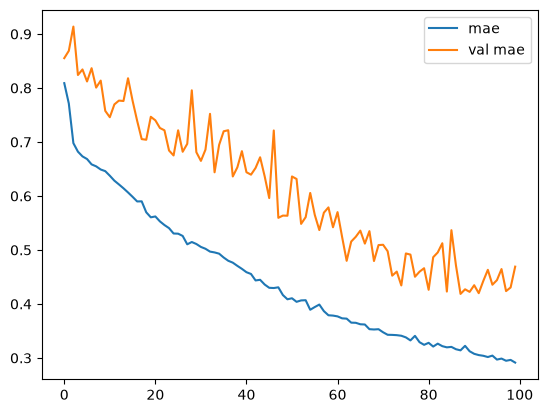

In [20]:
plt.plot(history_dict["mae"])
plt.plot(history_dict["val_mae"])
plt.legend(["mae", "val mae"])
plt.show()

In [21]:

from src.utils.dataframe_utils import create_dataframe


df = create_dataframe("../data/train.csv", "../data/boneage-training-dataset", segmented=False)
df_test = create_dataframe("../data/test.csv", "../data/boneage-test-dataset", segmented=False)
df_test_seg = create_dataframe("../data/test.csv", "../data/boneage-test-segmented", segmented=True)

In [22]:
from src.preprocessing.scaling import scaling_data
_, dataset_test, _ = scaling_data(df, df_test)
_, dataset_test_seg, _ = scaling_data(df, df_test)

In [23]:
from src.preprocessing.data_loader import load_image, create_dataset_tf

dataset_test = create_dataset_tf(dataset_test, load_image)
dataset_test_seg = create_dataset_tf(dataset_test_seg, load_image)

In [24]:
dataset_test_seg

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [25]:
"""
FIRST RESULTS ON TEST SET
"""

'\nFIRST RESULTS ON TEST SET\n'

In [26]:
m = 127.32
s = 41.18

In [27]:
import numpy as np

X_test = []
y_test = []

for x_batch, y_batch in dataset_test:
    X_test.append(x_batch.numpy())
    y_test.append(y_batch.numpy())

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)



In [28]:
y_pred = model.predict(X_test).flatten()
y_test = y_test.flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


In [29]:
y_pred

array([-4.11192030e-01,  1.01582873e+00,  5.68958104e-01,  2.11537480e-01,
       -1.59566253e-01,  6.86264753e-01,  5.21957159e-01, -5.46127439e-01,
       -4.31511670e-01,  1.09354508e+00, -1.75974834e+00,  1.53469598e+00,
        1.08525312e+00,  1.05188477e+00,  1.86097562e+00, -2.04876494e+00,
        4.52967227e-01,  2.52299815e-01,  8.50742102e-01,  5.29955864e-01,
        7.02782750e-01,  9.91223097e-01, -1.07364941e+00,  9.39076424e-01,
        1.01295543e+00,  6.72947228e-01,  9.94781971e-01,  1.26466644e+00,
       -1.42150950e+00, -8.19778323e-01,  6.76185668e-01, -1.49011374e+00,
       -2.53418624e-01, -2.45869011e-01, -6.60370588e-01,  7.15670109e-01,
       -5.97498536e-01, -2.31859803e+00, -1.63352513e+00,  2.50828177e-01,
        5.86195648e-01, -1.23336279e+00, -8.45750809e-01, -1.59449887e+00,
        2.18521327e-01, -1.29832149e-01,  8.33565474e-01,  6.08396411e-01,
        4.84726667e-01, -1.20444119e+00,  4.81553197e-01, -3.84643227e-01,
       -2.88048059e-01,  

In [30]:
y_pred = s * y_pred + m
y_test = s*y_test + m

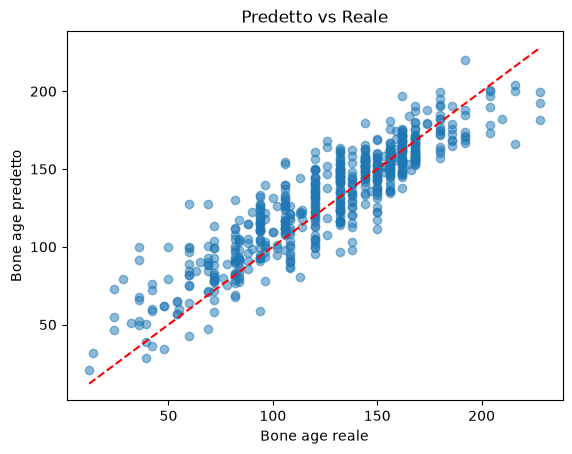

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Bone age reale")
plt.ylabel("Bone age predetto")
plt.title("Predetto vs Reale")
plt.show()


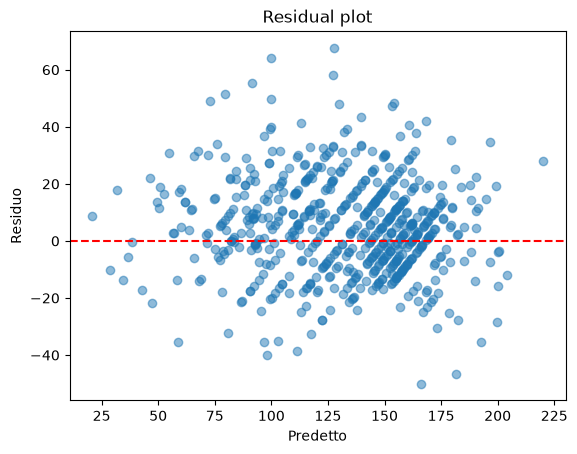

In [32]:
residuals = y_pred - y_test

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predetto")
plt.ylabel("Residuo")
plt.title("Residual plot")
plt.show()

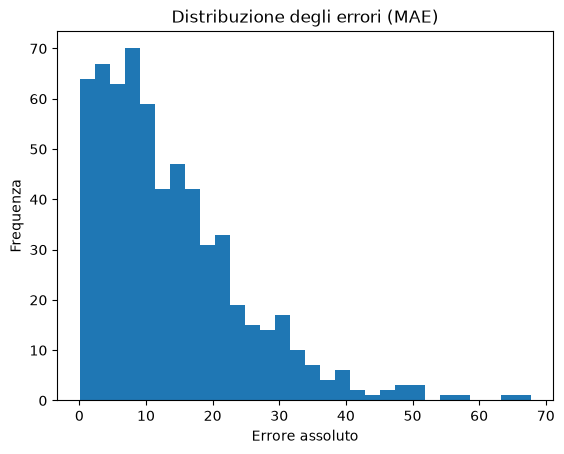

In [33]:
import numpy as np

errors = np.abs(y_test - y_pred)

plt.hist(errors, bins=30)
plt.xlabel("Errore assoluto")
plt.ylabel("Frequenza")
plt.title("Distribuzione degli errori (MAE)")
plt.show()


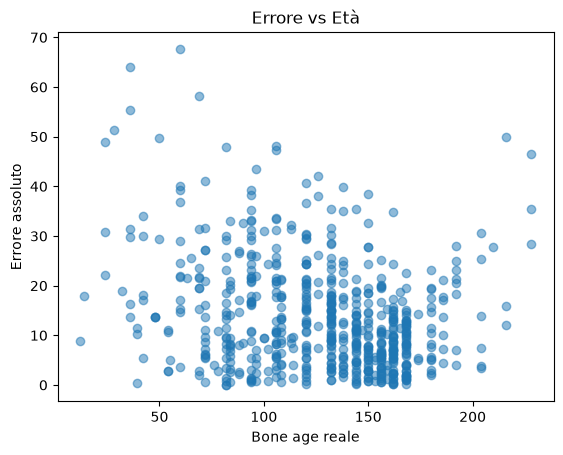

In [34]:
plt.scatter(y_test, errors, alpha=0.5)
plt.xlabel("Bone age reale")
plt.ylabel("Errore assoluto")
plt.title("Errore vs Età")
plt.show()


In [42]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)



MAE: 13.61130428314209
RMSE: 17.445350646972656


In [36]:
import numpy as np

X_test_seg = []
y_test_seg = []

for x_batch, y_batch in dataset_test_seg:
    X_test_seg.append(x_batch.numpy())
    y_test_seg.append(y_batch.numpy())

X_test_seg = np.concatenate(X_test_seg, axis=0)
y_test_seg = np.concatenate(y_test_seg, axis=0)

In [37]:
y_pred_seg = model.predict(X_test_seg).flatten()
y_test_seg = y_test_seg.flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


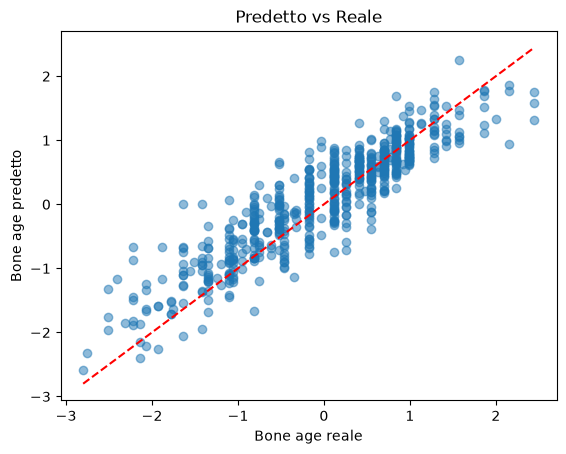

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test_seg, y_pred_seg, alpha=0.5)
plt.plot([y_test_seg.min(), y_test_seg.max()],
         [y_test_seg.min(), y_test_seg.max()],
         'r--')
plt.xlabel("Bone age reale")
plt.ylabel("Bone age predetto")
plt.title("Predetto vs Reale")
plt.show()

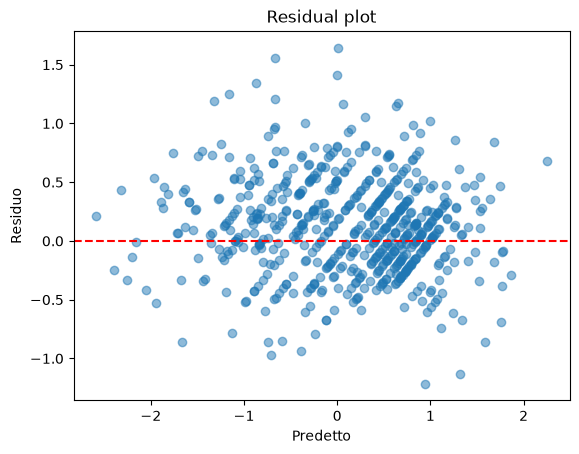

In [39]:
residuals = y_pred_seg - y_test_seg

plt.scatter(y_pred_seg, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predetto")
plt.ylabel("Residuo")
plt.title("Residual plot")
plt.show()

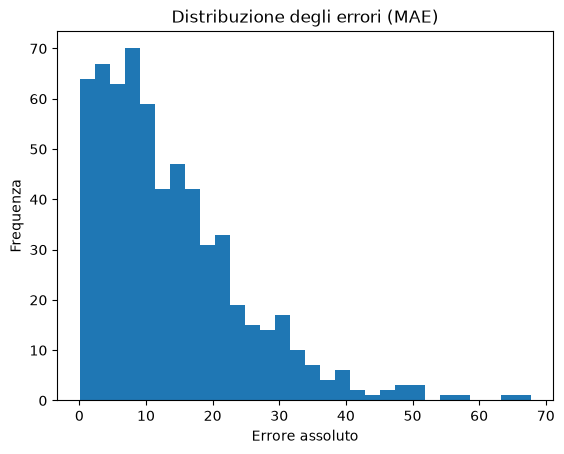

In [40]:
import numpy as np

errors = np.abs(y_test - y_pred)

plt.hist(errors, bins=30)
plt.xlabel("Errore assoluto")
plt.ylabel("Frequenza")
plt.title("Distribuzione degli errori (MAE)")
plt.show()


In [41]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_seg = mean_absolute_error(y_test_seg, y_pred_seg)
rmse_seg = root_mean_squared_error(y_test_seg, y_pred_seg)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13.61130428314209
RMSE: 17.445350646972656
